# 🌲 Entrenamiento de Proactive Forest para Predicción de Abandono Estudiantil

## Descripción del Notebook

Este notebook implementa un entrenamiento **clásico de Machine Learning** (sin aprendizaje federado) utilizando el algoritmo **Proactive Forest** sobre el dataset de abandono estudiantil (`students_dropout.csv`).

### Objetivos:
1. Cargar y preprocesar el dataset de estudiantes
2. Entrenar un modelo Proactive Forest
3. Evaluar el modelo mediante métricas de clasificación:
   - Matriz de Confusión
   - Accuracy (Precisión Global)
   - F1-Score (Macro y por clase)
   - Precision (Precisión por clase)
   - Recall (Sensibilidad por clase)

### Dataset
**Fuente:** `data/students_dropout.csv`  
**Variable objetivo:** `Target` (Dropout, Graduate, Enrolled)

---

## 📦 1. Importación de Librerías

Se importan todas las dependencias necesarias para:
- Carga y manipulación de datos (pandas, numpy)
- Preprocesamiento (sklearn)
- Visualización (matplotlib, seaborn)
- Modelo Proactive Forest (módulo personalizado)
- Métricas de evaluación (sklearn.metrics)

In [1]:
# ============================================================================
# LIBRERÍAS PARA MANIPULACIÓN DE DATOS
# ============================================================================
import pandas as pd
import numpy as np

# ============================================================================
# LIBRERÍAS PARA VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LIBRERÍAS PARA PREPROCESAMIENTO Y MÉTRICAS
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================================
# MÓDULOS PERSONALIZADOS - PROACTIVE FOREST
# ============================================================================
import sys
sys.path.append('../../../')

from src.domain.model.proactive_forest import ProactiveForest
from src.domain.metrics.forest_evaluator import ForestEvaluator

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## 📊 2. Carga y Exploración del Dataset

En esta sección cargamos el dataset y realizamos un análisis exploratorio inicial para comprender:
- La estructura de los datos
- Tipos de variables
- Distribución de la variable objetivo
- Valores nulos o faltantes

In [2]:
# ============================================================================
# CARGA DEL DATASET
# ============================================================================
# El dataset utiliza punto y coma (;) como separador
df = pd.read_csv(
    '../../../data/students_dropout.csv',
    sep=';',
    encoding='utf-8'
)

print(f"✅ Dataset cargado exitosamente")
print(f"📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
📊 Dimensiones: 4424 filas × 37 columnas


In [3]:
# ============================================================================
# VISUALIZACIÓN DE LAS PRIMERAS FILAS
# ============================================================================
# Mostramos las primeras 5 filas para entender la estructura
print("📋 Primeras 5 filas del dataset:")
df.head()

📋 Primeras 5 filas del dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# ============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
# Tipos de datos y valores no nulos por columna
print("=" * 80)
print("📝 INFORMACIÓN DEL DATASET")
print("=" * 80)
df.info()

📝 INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

In [5]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
# Resumen estadístico de variables numéricas
print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
df.describe()

📈 ESTADÍSTICAS DESCRIPTIVAS


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
# ============================================================================
# VERIFICACIÓN DE VALORES NULOS
# ============================================================================
# Contamos valores nulos por columna
print("🔍 Valores nulos por columna:")
null_counts = df.isnull().sum()
null_counts[null_counts > 0] if null_counts.sum() > 0 else print("✅ No hay valores nulos en el dataset")

🔍 Valores nulos por columna:
✅ No hay valores nulos en el dataset


## 🎯 3. Análisis de la Variable Objetivo

La variable `Target` indica el estado final del estudiante:
- **Dropout**: Abandono del curso
- **Graduate**: Graduación exitosa
- **Enrolled**: Continúa matriculado

Es crucial analizar su distribución para detectar posibles desbalanceos de clases.

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)
          Cantidad  Porcentaje (%)
Target                            
Graduate      2209       49.932188
Dropout       1421       32.120253
Enrolled       794       17.947559


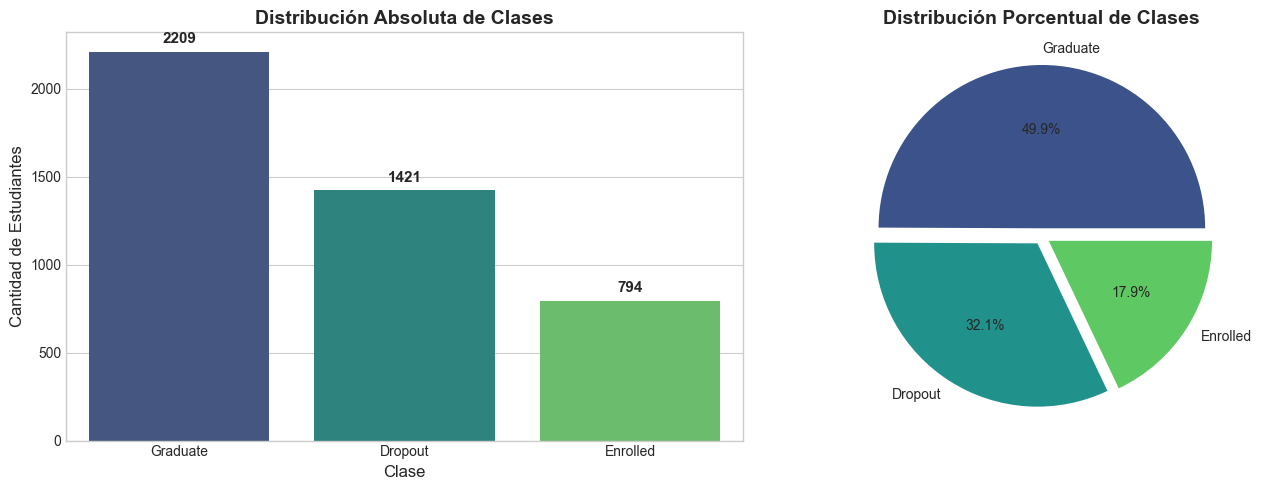


⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.
   Se recomienda usar métricas como F1-Score y no solo Accuracy.


In [7]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)")
print("=" * 80)
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct
})
print(distribution_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad de Estudiantes', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

# Gráfico de torta
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(target_counts)),
    explode=[0.05] * len(target_counts)
)
axes[1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.")
print(f"   Se recomienda usar métricas como F1-Score y no solo Accuracy.")

## 🔧 4. Preprocesamiento de Datos

### Pasos de Preprocesamiento:
1. **Separación de características y variable objetivo**: Dividir el dataset en features (X) y target (y)
2. **Codificación de etiquetas**: Convertir las clases a valores numéricos
3. **División train-test**: Separar en conjunto de entrenamiento y prueba (80%-20%)

In [8]:
# ============================================================================
# SEPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO
# ============================================================================
# X: Todas las columnas excepto 'Target'
# y: Columna 'Target'
X = df.drop('Target', axis=1)
y = df['Target']

print(f"✅ Features (X): {X.shape}")
print(f"✅ Target (y): {y.shape}")
print(f"\n📋 Columnas del dataset ({len(X.columns)} características):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Features (X): (4424, 36)
✅ Target (y): (4424,)

📋 Columnas del dataset (36 características):
    1. Marital status
    2. Application mode
    3. Application order
    4. Course
    5. Daytime/evening attendance
    6. Previous qualification
    7. Previous qualification (grade)
    8. Nacionality
    9. Mother's qualification
   10. Father's qualification
   11. Mother's occupation
   12. Father's occupation
   13. Admission grade
   14. Displaced
   15. Educational special needs
   16. Debtor
   17. Tuition fees up to date
   18. Gender
   19. Scholarship holder
   20. Age at enrollment
   21. International
   22. Curricular units 1st sem (credited)
   23. Curricular units 1st sem (enrolled)
   24. Curricular units 1st sem (evaluations)
   25. Curricular units 1st sem (approved)
   26. Curricular units 1st sem (grade)
   27. Curricular units 1st sem (without evaluations)
   28. Curricular units 2nd sem (credited)
   29. Curricular units 2nd sem (enrolled)
   30. Curricular units 2n

In [9]:
# ============================================================================
# CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
# Convertimos las clases a valores numéricos para el entrenamiento
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Guardamos el mapeo de clases para interpretación posterior
class_names = label_encoder.classes_.tolist()
class_mapping = {cls: idx for idx, cls in enumerate(class_names)}

print("=" * 80)
print("🔢 MAPEO DE CLASES (Codificación)")
print("=" * 80)
for cls, idx in class_mapping.items():
    print(f"   {cls:12} → {idx}")

print(f"\n✅ Variable objetivo codificada: {len(y_encoded)} muestras")

🔢 MAPEO DE CLASES (Codificación)
   Dropout      → 0
   Enrolled     → 1
   Graduate     → 2

✅ Variable objetivo codificada: 4424 muestras


In [10]:
# ============================================================================
# DIVISIÓN TRAIN-TEST
# ============================================================================
# Separamos el dataset en 80% entrenamiento y 20% prueba
# stratify=y_encoded mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,           # 20% para prueba
    random_state=42,         # Semilla para reproducibilidad
    stratify=y_encoded       # Estratificación para mantener proporción de clases
)

print("=" * 80)
print("📊 DIVISIÓN DEL DATASET")
print("=" * 80)
print(f"\n🔹 Conjunto de ENTRENAMIENTO:")
print(f"   - Muestras: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Features: {X_train.shape[1]}")
print(f"\n🔹 Conjunto de PRUEBA:")
print(f"   - Muestras: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Features: {X_test.shape[1]}")

# Verificar distribución de clases en train y test
print(f"\n📋 Distribución de clases en TRAIN:")
for cls, idx in class_mapping.items():
    count = sum(y_train == idx)
    pct = count / len(y_train) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

print(f"\n📋 Distribución de clases en TEST:")
for cls, idx in class_mapping.items():
    count = sum(y_test == idx)
    pct = count / len(y_test) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

📊 DIVISIÓN DEL DATASET

🔹 Conjunto de ENTRENAMIENTO:
   - Muestras: 3539 (80.0%)
   - Features: 36

🔹 Conjunto de PRUEBA:
   - Muestras: 885 (20.0%)
   - Features: 36

📋 Distribución de clases en TRAIN:
   - Dropout     : 1137 muestras (32.13%)
   - Enrolled    :  635 muestras (17.94%)
   - Graduate    : 1767 muestras (49.93%)

📋 Distribución de clases en TEST:
   - Dropout     :  284 muestras (32.09%)
   - Enrolled    :  159 muestras (17.97%)
   - Graduate    :  442 muestras (49.94%)


## 🌲 5. Entrenamiento del Proactive Forest

### Configuración del Modelo

**Proactive Forest** es un algoritmo basado en el **Comparative Progressive Forest (CPF)** que:
- Construye árboles de decisión de forma progresiva
- Utiliza un mecanismo de early stopping basado en validación
- Incorpora diversidad en la selección de características

### Hiperparámetros:
- `n_estimators`: Número de árboles en el bosque
- `alpha`: Tasa de diversidad para ajuste de probabilidades de features
- `random_state`: Semilla aleatoria para reproducibilidad
- `verbose`: Mostrar logs de entrenamiento

In [11]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO PROACTIVE FOREST
# ============================================================================
# Definimos los hiperparámetros del modelo
N_ESTIMATORS = 100    # Número de árboles en el bosque
ALPHA = 0.1           # Tasa de diversidad (parámetro de Cepero)
RANDOM_STATE = 42     # Semilla para reproducibilidad
VERBOSE = True        # Mostrar progreso del entrenamiento

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO")
print("=" * 80)
print(f"🌲 Número de árboles (n_estimators): {N_ESTIMATORS}")
print(f"🎲 Tasa de diversidad (alpha): {ALPHA}")
print(f"🎯 Semilla aleatoria (random_state): {RANDOM_STATE}")
print(f"📝 Verbose: {VERBOSE}")
print(f"🏷️  Clases: {class_names}")

⚙️ CONFIGURACIÓN DEL MODELO
🌲 Número de árboles (n_estimators): 100
🎲 Tasa de diversidad (alpha): 0.1
🎯 Semilla aleatoria (random_state): 42
📝 Verbose: True
🏷️  Clases: ['Dropout', 'Enrolled', 'Graduate']


In [12]:
# ============================================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================
print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST")
print("=" * 80)
print(f"\n📊 Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"⏳ Tiempo estimado: ~30-60 segundos...\n")

# Crear el modelo Proactive Forest
model = ProactiveForest(
    n_estimators=N_ESTIMATORS,
    alpha=ALPHA,
    random_state=RANDOM_STATE,
    verbose=VERBOSE,
    class_names=class_names
)

# Entrenar el modelo
model.fit(X_train.values, y_train)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 80)

🚀 INICIANDO ENTRENAMIENTO DEL PROACTIVE FOREST

📊 Datos de entrenamiento: 3539 muestras, 36 features
⏳ Tiempo estimado: ~30-60 segundos...

  Árbol 1 | acc=0.7133
  Árbol 2 | acc=0.6977
  Árbol 3 | acc=0.6963
  Árbol 4 | acc=0.6822
  Árbol 5 | acc=0.6808
  [CPF] No converge, siguiente episodio=6
  [CPF] Árboles construidos=5, próximo episodio=6
  ----------------------------------------
  Árbol 6 | acc=0.6751
  Árbol 7 | acc=0.6921
  Árbol 8 | acc=0.6723
  Árbol 9 | acc=0.6624
  Árbol 10 | acc=0.6794
  Árbol 11 | acc=0.6497
  [CPF] No converge, siguiente episodio=7
  [CPF] Árboles construidos=11, próximo episodio=7
  ----------------------------------------
  Árbol 12 | acc=0.6935
  Árbol 13 | acc=0.6667
  Árbol 14 | acc=0.6610
  Árbol 15 | acc=0.6822
  Árbol 16 | acc=0.6667
  Árbol 17 | acc=0.6412
  Árbol 18 | acc=0.6963
  [CPF] No converge, siguiente episodio=8
  [CPF] Árboles construidos=18, próximo episodio=8
  ----------------------------------------
  Árbol 19 | acc=0.6624
  Árbo

In [13]:
# ============================================================================
# INFORMACIÓN DEL MODELO ENTRENADO
# ============================================================================
# Obtenemos información sobre el bosque entrenado
trees = model.get_trees()

print("=" * 80)
print("📊 INFORMACIÓN DEL MODELO ENTRENADO")
print("=" * 80)
print(f"\n🌲 Número de árboles en el bosque: {len(trees)}")
print(f"📏 Número de features: {X_train.shape[1]}")
print(f"🏷️  Número de clases: {len(class_names)}")
print(f"📝 Clases: {class_names}")

📊 INFORMACIÓN DEL MODELO ENTRENADO

🌲 Número de árboles en el bosque: 33
📏 Número de features: 36
🏷️  Número de clases: 3
📝 Clases: ['Dropout', 'Enrolled', 'Graduate']


## 🔮 6. Predicción en el Conjunto de Prueba

Una vez entrenado el modelo, realizamos predicciones sobre el conjunto de prueba (test) para evaluar su capacidad de generalización.

In [14]:
# ============================================================================
# PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Realizando predicciones en el conjunto de prueba...")

# Generar predicciones
y_pred = model.predict(X_test.values)

print(f"✅ Predicciones completadas: {len(y_pred)} muestras")
print(f"\n📋 Primeras 10 predicciones vs valores reales:")
print("-" * 60)
for i in range(min(10, len(y_pred))):
    real_cls = label_encoder.inverse_transform([y_test[i]])[0]
    pred_cls = label_encoder.inverse_transform([y_pred[i]])[0]
    match = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"   {i+1:2d}. Real: {real_cls:12} | Pred: {pred_cls:12} {match}")

🔮 Realizando predicciones en el conjunto de prueba...
✅ Predicciones completadas: 885 muestras

📋 Primeras 10 predicciones vs valores reales:
------------------------------------------------------------
    1. Real: Graduate     | Pred: Graduate     ✓
    2. Real: Graduate     | Pred: Graduate     ✓
    3. Real: Enrolled     | Pred: Dropout      ✗
    4. Real: Graduate     | Pred: Graduate     ✓
    5. Real: Graduate     | Pred: Graduate     ✓
    6. Real: Graduate     | Pred: Enrolled     ✗
    7. Real: Graduate     | Pred: Graduate     ✓
    8. Real: Graduate     | Pred: Graduate     ✓
    9. Real: Graduate     | Pred: Graduate     ✓
   10. Real: Graduate     | Pred: Graduate     ✓


## 📈 7. Evaluación del Modelo - Métricas de Clasificación

### Métricas a Calcular:

1. **Matriz de Confusión**: Tabla que muestra aciertos y errores por clase
2. **Accuracy (Precisión Global)**: Porcentaje total de predicciones correctas
3. **Precision (Precisión por clase)**: De los que predije como clase X, ¿cuántos realmente lo eran?
4. **Recall (Sensibilidad por clase)**: De los que realmente eran clase X, ¿cuántos identifiqué?
5. **F1-Score**: Media armónica entre Precision y Recall (balancea ambas métricas)

### Fórmulas:
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)

In [15]:
# ============================================================================
# CÁLCULO DE MÉTRICAS USANDO FOREST EVALUATOR
# ============================================================================
# Utilizamos el evaluador personalizado del proyecto
from src.domain.metrics.forest_evaluator import ForestEvaluator

print("=" * 80)
print("📊 CALCULANDO MÉTRICAS DE EVALUACIÓN")
print("=" * 80)

# Evaluar el modelo usando el ForestEvaluator
# Nota: Necesitamos acceder al classifier interno del modelo
forest_classifier = model._classifier

report = ForestEvaluator.evaluate(
    forest=forest_classifier,
    X=X_test.values,
    y=y_test,
    class_names=class_names
)

print(f"\n✅ Métricas calculadas exitosamente")

📊 CALCULANDO MÉTRICAS DE EVALUACIÓN

✅ Métricas calculadas exitosamente


In [16]:
# ============================================================================
# REPORTE DE MÉTRICAS GLOBALES
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

print(f"\n🎯 Accuracy (Precisión Global):     {report.accuracy:.4f} ({report.accuracy*100:.2f}%)")
print(f"📈 Macro F1-Score:                   {report.macro_f1:.4f} ({report.macro_f1*100:.2f}%)")
print(f"📊 Macro Precision:                  {report.macro_precision:.4f} ({report.macro_precision*100:.2f}%)")
print(f"📉 Macro Recall:                     {report.macro_recall:.4f} ({report.macro_recall*100:.2f}%)")
print(f"\n🌲 Tamaño del Bosque:                {report.forest_size} árboles")
print(f"🔄 PCD (Diversidad):                 {report.pcd:.4f}")

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN DE MÉTRICAS")
print("=" * 80)
print(f"""
• Accuracy ({report.accuracy:.2%}): De todas las predicciones, el {report.accuracy:.2%} fueron correctas.
• Macro F1-Score ({report.macro_f1:.2%}): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision ({report.macro_precision:.2%}): Promedio de precisión por clase.
• Macro Recall ({report.macro_recall:.2%}): Promedio de sensibilidad por clase.
""")

📊 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy (Precisión Global):     0.7525 (75.25%)
📈 Macro F1-Score:                   0.6806 (68.06%)
📊 Macro Precision:                  0.6953 (69.53%)
📉 Macro Recall:                     0.6728 (67.28%)

🌲 Tamaño del Bosque:                33 árboles
🔄 PCD (Diversidad):                 0.0000

💡 INTERPRETACIÓN DE MÉTRICAS

• Accuracy (75.25%): De todas las predicciones, el 75.25% fueron correctas.
• Macro F1-Score (68.06%): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision (69.53%): Promedio de precisión por clase.
• Macro Recall (67.28%): Promedio de sensibilidad por clase.



📊 MÉTRICAS POR CLASE

📋 Tabla de métricas por clase:
         Precision Recall F1-Score
Dropout     0.7977 0.7218   0.7579
Enrolled    0.4922 0.3962   0.4390
Graduate    0.7960 0.9005   0.8450


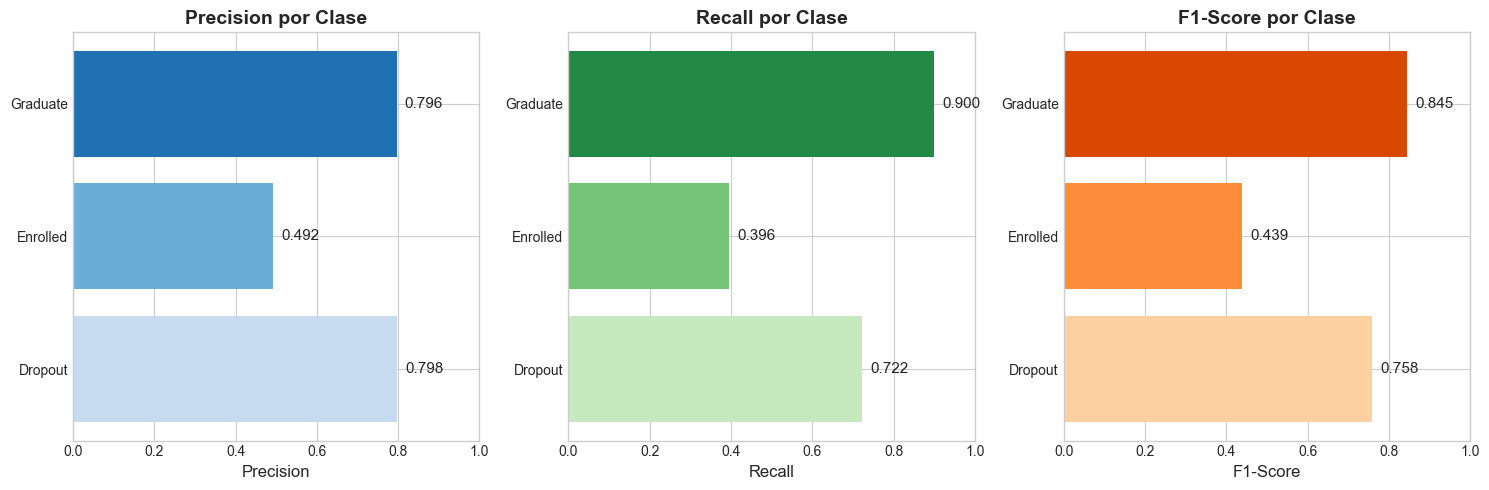

In [17]:
# ============================================================================
# MÉTRICAS POR CLASE
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS POR CLASE")
print("=" * 80)

# Crear DataFrame con métricas por clase
metrics_by_class = pd.DataFrame({
    'Precision': report.per_class_prec,
    'Recall': report.per_class_recall,
    'F1-Score': report.per_class_f1
})

print("\n📋 Tabla de métricas por clase:")
print(metrics_by_class.to_string(
    formatters={
        'Precision': '{:.4f}'.format,
        'Recall': '{:.4f}'.format,
        'F1-Score': '{:.4f}'.format
    }
))

# Visualización de métricas por clase
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision por clase
colors_prec = sns.color_palette('Blues', len(class_names))
bars1 = axes[0].barh(metrics_by_class.index, metrics_by_class['Precision'], color=colors_prec)
axes[0].set_title('Precision por Clase', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precision', fontsize=12)
axes[0].set_xlim(0, 1)
for i, v in enumerate(metrics_by_class['Precision']):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11)

# Recall por clase
colors_rec = sns.color_palette('Greens', len(class_names))
bars2 = axes[1].barh(metrics_by_class.index, metrics_by_class['Recall'], color=colors_rec)
axes[1].set_title('Recall por Clase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_xlim(0, 1)
for i, v in enumerate(metrics_by_class['Recall']):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11)

# F1-Score por clase
colors_f1 = sns.color_palette('Oranges', len(class_names))
bars3 = axes[2].barh(metrics_by_class.index, metrics_by_class['F1-Score'], color=colors_f1)
axes[2].set_title('F1-Score por Clase', fontsize=14, fontweight='bold')
axes[2].set_xlabel('F1-Score', fontsize=12)
axes[2].set_xlim(0, 1)
for i, v in enumerate(metrics_by_class['F1-Score']):
    axes[2].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

## 🔀 8. Matriz de Confusión

La **Matriz de Confusión** es una tabla que permite visualizar el desempeño del algoritmo de clasificación:

### Estructura:
- **Filas**: Valores reales (True labels)
- **Columnas**: Valores predichos (Predicted labels)

### Interpretación:
- **Diagonal principal**: Predicciones correctas (TP por clase)
- **Fuera de la diagonal**: Errores de clasificación

🔀 MATRIZ DE CONFUSIÓN

📋 Matriz de confusión (valores absolutos):

     Predicho →     Dropout    Enrolled    Graduate
-----------------------------------------------------------------
Real: Dropout          205          34          45
Real: Enrolled          39          63          57
Real: Graduate          13          31         398


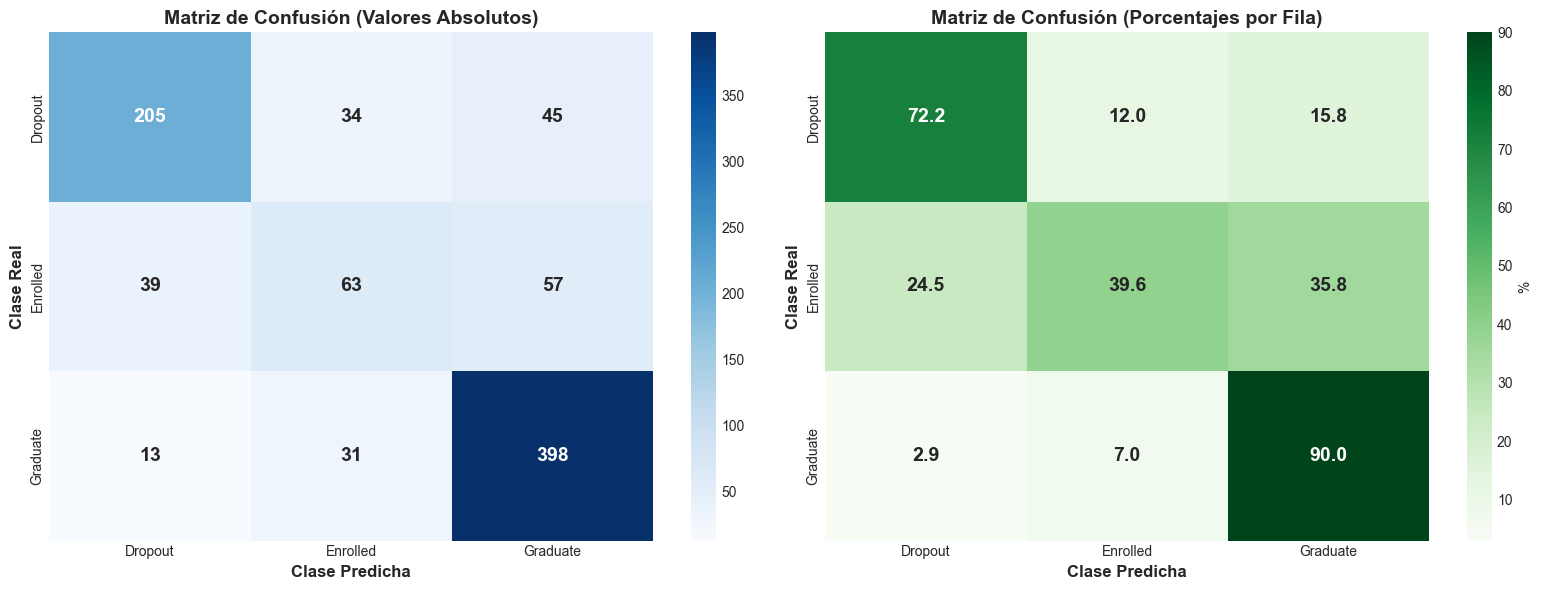


🔍 ANÁLISIS DE ERRORES

❌ Total de errores: 219 de 885 muestras (24.75%)
✅ Total de aciertos: 666 de 885 muestras (75.25%)

📋 Errores de clasificación más comunes:
   • Enrolled     → Graduate    :   57 casos
   • Dropout      → Graduate    :   45 casos
   • Enrolled     → Dropout     :   39 casos
   • Dropout      → Enrolled    :   34 casos
   • Graduate     → Enrolled    :   31 casos


In [18]:
# ============================================================================
# MATRIZ DE CONFUSIÓN - VISUALIZACIÓN
# ============================================================================
print("=" * 80)
print("🔀 MATRIZ DE CONFUSIÓN")
print("=" * 80)

cm = report.confusion_matrix

print("\n📋 Matriz de confusión (valores absolutos):")
print(f"\n{'Predicho →':>15}", end="")
for cls in class_names:
    print(f"{cls:>12}", end="")
print("\n" + "-" * 65)

for i, cls in enumerate(class_names):
    print(f"Real: {cls:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i, j]:>12}", end="")
    print()

# Visualización heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap con valores absolutos
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Matriz de Confusión (Valores Absolutos)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase Predicha', fontsize=12, fontweight='bold')

# Heatmap con porcentajes por fila
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'},
    cbar_kws={'label': '%'}
)
axes[1].set_title('Matriz de Confusión (Porcentajes por Fila)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase Predicha', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de errores
print("\n" + "=" * 80)
print("🔍 ANÁLISIS DE ERRORES")
print("=" * 80)

total_errors = cm.sum() - np.trace(cm)
error_rate = total_errors / cm.sum() * 100

print(f"\n❌ Total de errores: {total_errors} de {cm.sum()} muestras ({error_rate:.2f}%)")
print(f"✅ Total de aciertos: {int(np.trace(cm))} de {cm.sum()} muestras ({100-error_rate:.2f}%)")

# Identificar los errores más comunes
print("\n📋 Errores de clasificación más comunes:")
error_matrix = cm.copy()
np.fill_diagonal(error_matrix, 0)  # Poner a 0 los aciertos

errors = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if error_matrix[i, j] > 0:
            errors.append((class_names[i], class_names[j], error_matrix[i, j]))

errors.sort(key=lambda x: x[2], reverse=True)

for real_cls, pred_cls, count in errors[:5]:  # Top 5 errores
    print(f"   • {real_cls:12} → {pred_cls:12}: {count:4d} casos")

## 📋 9. Reporte de Clasificación (Classification Report)

Generamos un reporte completo utilizando las funciones de scikit-learn para tener una visión consolidada de todas las métricas.

In [19]:
# ============================================================================
# CLASSIFICATION REPORT DE SKLEARN
# ============================================================================
print("=" * 80)
print("📋 CLASSIFICATION REPORT (SKLEARN)")
print("=" * 80)

# Generar reporte de clasificación
target_names = class_names  # Nombres de las clases

report_sklearn = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    output_dict=False,  # Output como string
    digits=4
)

print("\n" + report_sklearn)

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN DEL REPORTE")
print("=" * 80)
print("""
• precision: De todos los predichos como clase X, ¿cuántos realmente lo eran?
• recall: De todos los que realmente eran clase X, ¿cuántos identificó?
• f1-score: Media armónica entre precision y recall (balancea ambas)
• support: Número de muestras reales de cada clase

• accuracy: Precisión global del modelo
• macro avg: Promedio simple de las métricas por clase (no ponderado)
• weighted avg: Promedio ponderado por el support de cada clase
""")

📋 CLASSIFICATION REPORT (SKLEARN)

              precision    recall  f1-score   support

     Dropout     0.7977    0.7218    0.7579       284
    Enrolled     0.4922    0.3962    0.4390       159
    Graduate     0.7960    0.9005    0.8450       442

    accuracy                         0.7525       885
   macro avg     0.6953    0.6728    0.6806       885
weighted avg     0.7420    0.7525    0.7441       885


💡 INTERPRETACIÓN DEL REPORTE

• precision: De todos los predichos como clase X, ¿cuántos realmente lo eran?
• recall: De todos los que realmente eran clase X, ¿cuántos identificó?
• f1-score: Media armónica entre precision y recall (balancea ambas)
• support: Número de muestras reales de cada clase

• accuracy: Precisión global del modelo
• macro avg: Promedio simple de las métricas por clase (no ponderado)
• weighted avg: Promedio ponderado por el support de cada clase



## 📊 10. Resumen Visual de Métricas

Creamos una visualización consolidada de todas las métricas para una interpretación rápida del desempeño del modelo.

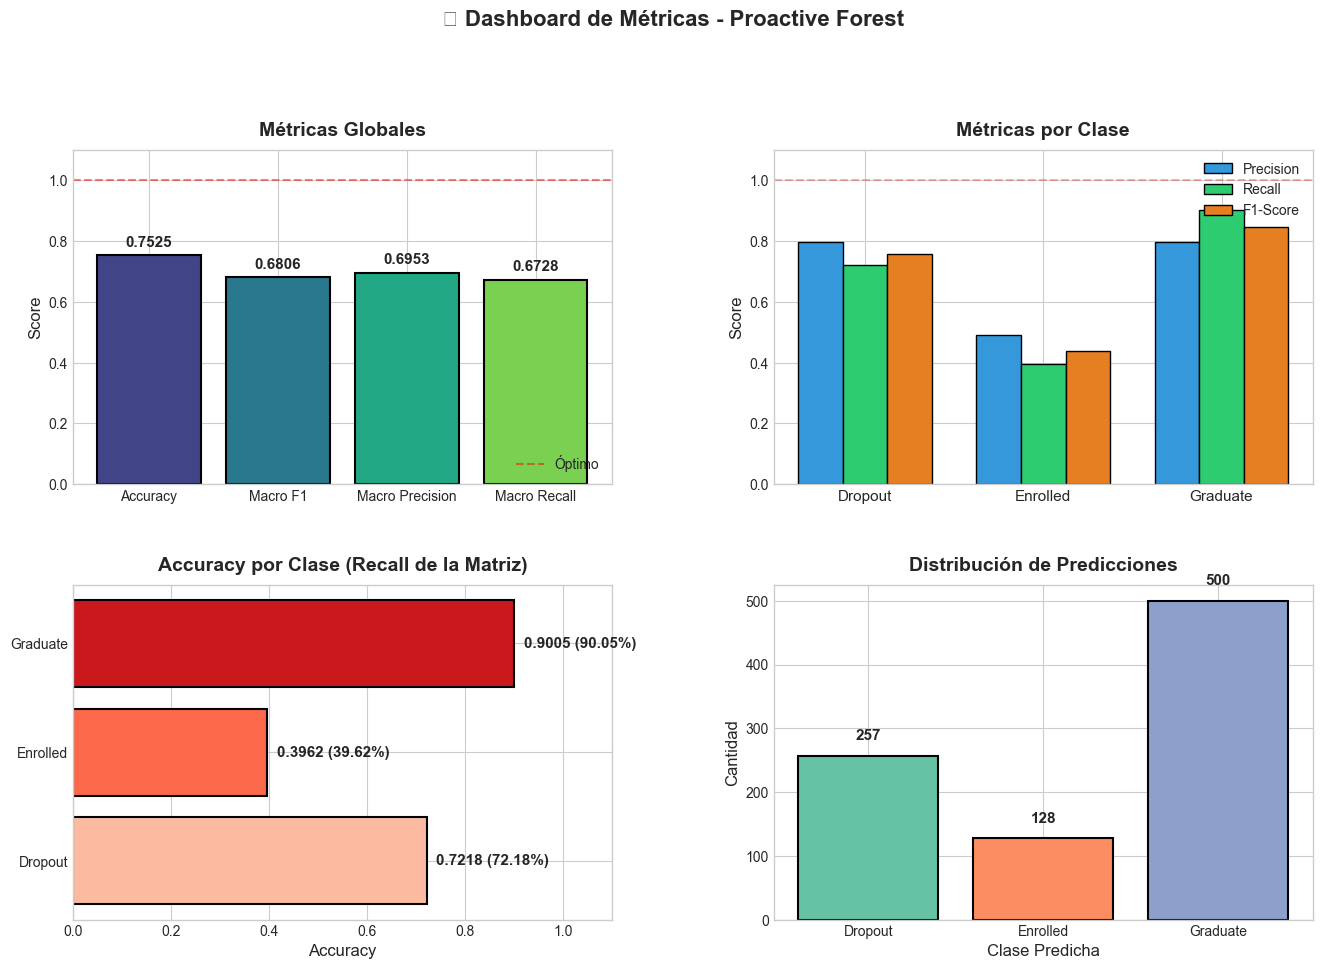

In [20]:
# ============================================================================
# DASHBOARD DE MÉTRICAS
# ============================================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Métricas globales (barras)
ax1 = fig.add_subplot(gs[0, 0])
global_metrics = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
global_values = [
    report.accuracy,
    report.macro_f1,
    report.macro_precision,
    report.macro_recall
]
colors_global = sns.color_palette('viridis', len(global_metrics))
bars1 = ax1.bar(global_metrics, global_values, color=colors_global, edgecolor='black', linewidth=1.5)
ax1.set_title('Métricas Globales', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Óptimo')
ax1.legend(loc='lower right')
for bar, val in zip(bars1, global_values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# 2. Comparativa por clase (radar chart simplificado como barras agrupadas)
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(class_names))
width = 0.25
multiplier = 0

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
colors_metrics = ['#3498db', '#2ecc71', '#e67e22']

for metric, color in zip(metrics_to_plot, colors_metrics):
    offset = multiplier * width
    values = metrics_by_class[metric].values
    rects = ax2.bar(x + offset, values, width, label=metric, color=color, edgecolor='black', linewidth=1)
    multiplier += 1

ax2.set_title('Métricas por Clase', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(class_names, fontsize=11)
ax2.set_ylim(0, 1.1)
ax2.legend(loc='upper right')
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)

# 3. Accuracy por clase (de la diagonal de la matriz)
ax3 = fig.add_subplot(gs[1, 0])
class_accuracy = np.diag(cm) / cm.sum(axis=1)
colors_acc = sns.color_palette('Reds', len(class_names))
bars3 = ax3.barh(class_names, class_accuracy, color=colors_acc, edgecolor='black', linewidth=1.5)
ax3.set_title('Accuracy por Clase (Recall de la Matriz)', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Accuracy', fontsize=12)
ax3.set_xlim(0, 1.1)
for bar, val in zip(bars3, class_accuracy):
    ax3.text(
        val + 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f} ({val*100:.2f}%)',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# 4. Distribución de predicciones
ax4 = fig.add_subplot(gs[1, 1])
unique, counts = np.unique(y_pred, return_counts=True)
pred_labels = [label_encoder.inverse_transform([u])[0] for u in unique]
colors_pred = sns.color_palette('Set2', len(pred_labels))
bars4 = ax4.bar(pred_labels, counts, color=colors_pred, edgecolor='black', linewidth=1.5)
ax4.set_title('Distribución de Predicciones', fontsize=14, fontweight='bold', pad=10)
ax4.set_ylabel('Cantidad', fontsize=12)
ax4.set_xlabel('Clase Predicha', fontsize=12)
for bar, count in zip(bars4, counts):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        str(count),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.suptitle('📊 Dashboard de Métricas - Proactive Forest', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 🎯 11. Conclusiones y Recomendaciones

### Resumen del Entrenamiento

In [21]:
# ============================================================================
# RESUMEN FINAL DEL MODELO
# ============================================================================
print("=" * 80)
print("🎯 RESUMEN FINAL DEL ENTRENAMIENTO")
print("=" * 80)

print(f"""
📊 DATASET:
   • Dataset: students_dropout.csv
   • Muestras totales: {len(df)}
   • Características: {X.shape[1]}
   • Clases: {class_names}

🔧 CONFIGURACIÓN:
   • Modelo: Proactive Forest (CPF Algorithm)
   • Árboles: {len(trees)}
   • Alpha (diversidad): {ALPHA}
   • Train/Test: 80%/20%

📈 RESULTADOS:
   • Accuracy:           {report.accuracy:.4f} ({report.accuracy*100:.2f}%)
   • Macro F1-Score:     {report.macro_f1:.4f} ({report.macro_f1*100:.2f}%)
   • Macro Precision:    {report.macro_precision:.4f} ({report.macro_precision*100:.2f}%)
   • Macro Recall:       {report.macro_recall:.4f} ({report.macro_recall*100:.2f}%)
   • PCD (Diversidad):   {report.pcd:.4f}

🏆 MEJOR CLASE (por F1-Score):
   • {max(report.per_class_f1, key=report.per_class_f1.get)}: {max(report.per_class_f1.values()):.4f}

⚠️  CLASE MÁS DÉBIL (por F1-Score):
   • {min(report.per_class_f1, key=report.per_class_f1.get)}: {min(report.per_class_f1.values()):.4f}
""")

print("=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("=" * 80)

🎯 RESUMEN FINAL DEL ENTRENAMIENTO

📊 DATASET:
   • Dataset: students_dropout.csv
   • Muestras totales: 4424
   • Características: 36
   • Clases: ['Dropout', 'Enrolled', 'Graduate']

🔧 CONFIGURACIÓN:
   • Modelo: Proactive Forest (CPF Algorithm)
   • Árboles: 33
   • Alpha (diversidad): 0.1
   • Train/Test: 80%/20%

📈 RESULTADOS:
   • Accuracy:           0.7525 (75.25%)
   • Macro F1-Score:     0.6806 (68.06%)
   • Macro Precision:    0.6953 (69.53%)
   • Macro Recall:       0.6728 (67.28%)
   • PCD (Diversidad):   0.0000

🏆 MEJOR CLASE (por F1-Score):
   • Graduate: 0.8450

⚠️  CLASE MÁS DÉBIL (por F1-Score):
   • Enrolled: 0.4390

✅ ENTRENAMIENTO COMPLETADO


### 📝 Recomendaciones para Mejorar el Modelo

1. **Balanceo de Clases**: El dataset presenta desbalanceo. Considerar técnicas como:
   - SMOTE (Synthetic Minority Over-sampling Technique)
   - Undersampling de la clase mayoritaria
   - Ponderación de clases en el entrenamiento

2. **Selección de Features**: Reducir las 35+ características a las más relevantes mediante:
   - Importancia de características del Random Forest
   - Recursive Feature Elimination (RFE)
   - Correlation analysis

3. **Optimización de Hiperparámetros**: Realizar Grid Search o Random Search para:
   - `n_estimators`: Probar valores entre 50-200
   - `alpha`: Probar valores entre 0.05-0.3
   - `max_depth`: Profundidad máxima de los árboles

4. **Validación Cruzada**: Implementar k-fold cross-validation para una evaluación más robusta

5. **Ensemble Methods**: Considerar combinar con otros algoritmos como:
   - XGBoost
   - LightGBM
   - Gradient Boosting

---

## 📚 Referencias

1. **Cepero, M. (2023)**. Comparative Progressive Forest (CPF) Algorithm.
2. **Breiman, L. (2001)**. Random Forests. Machine Learning, 45(1), 5-32.
3. **Scikit-learn Documentation**. Metrics and Evaluation.
4. **Dataset**: Students Dropout Dataset (Universidad portuguesa)

---

**Autor:** Notebook generado para el proyecto Federated Proactive Forest  
**Fecha:** 2026  
**Licencia:** Uso académico y de investigación